# Lab 1: Image Manipulation and Filtering

## Theory

### Experiment 1: Image Representation
A digital image is a two-dimensional function f(x, y), where x and y represent spatial coordinates and the value of f at any point represents the intensity of the image at that location. In digital form, this function is discretized into a matrix of size M × N.

For grayscale images, each pixel is represented by a single intensity value. In an 8-bit image, the intensity ranges from 0 to 255, where 0 represents black and 255 represents white. This discrete representation allows efficient storage and processing of images.

---

### Experiment 2: Noise Models

#### Gaussian Noise
Gaussian noise is a type of statistical noise with a probability density function equal to a normal distribution. It affects all pixels in the image and is commonly introduced during image acquisition due to sensor noise, poor lighting, or thermal effects.

Mathematically:
g(x, y) = f(x, y) + n(x, y)

where n(x, y) follows a Gaussian distribution.

#### Salt and Pepper Noise
Salt and Pepper noise is an impulse noise where random pixels are replaced by either minimum (0) or maximum (255) intensity values. It appears as white and black dots in the image and is typically caused by transmission errors or hardware faults.

---

### Experiment 3: Spatial Filtering

Spatial filtering involves modifying the intensity of a pixel based on its neighboring pixels using a kernel.

#### Averaging Filter
It replaces each pixel with the average of its neighbors, resulting in smoothing. However, it tends to blur edges.

#### Gaussian Filter
Uses a weighted average based on a Gaussian function. It provides smoother and more natural blurring compared to averaging filters.

#### Median Filter
A non-linear filter that replaces the pixel value with the median of neighboring values. It is highly effective in removing salt and pepper noise while preserving edges.

In [2]:
import cv2

# Load image
img = cv2.imread('image.jpg')

# Display image
cv2.imshow('Original Image', img)

# Print properties
print("Shape:", img.shape)
print("Size:", img.size)
print("Data type:", img.dtype)

cv2.waitKey(0)
cv2.destroyAllWindows()

Shape: (2268, 4032, 3)
Size: 27433728
Data type: uint8


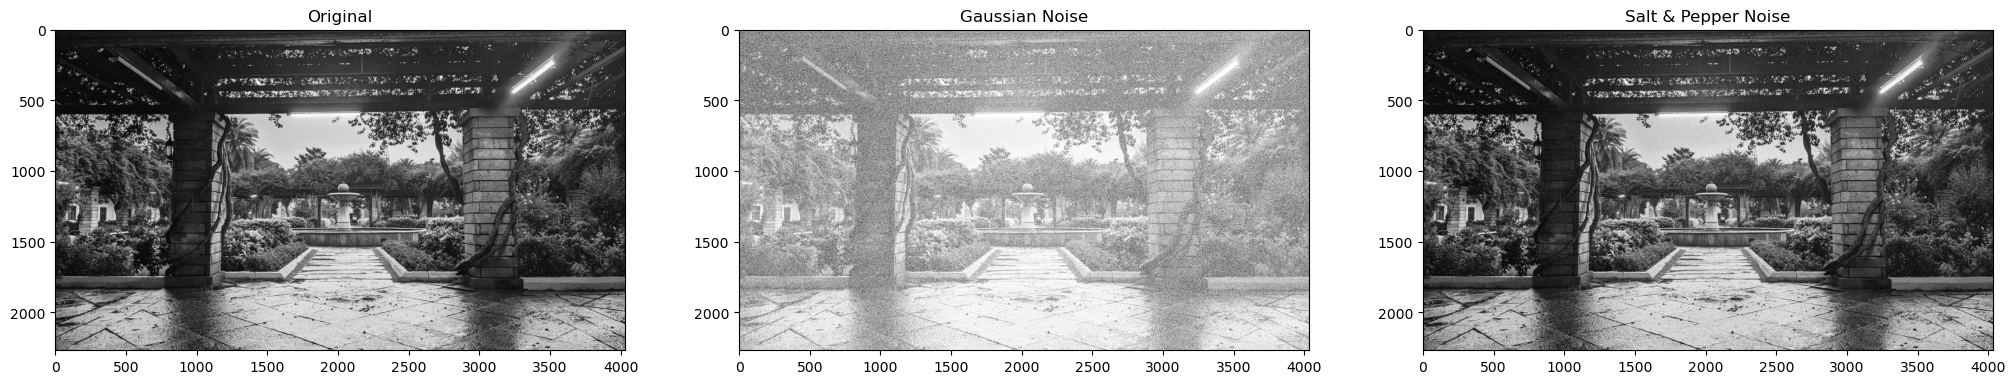

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image in grayscale
img = cv2.imread('image.jpg', 0)

# ---------- Gaussian Noise ----------
mean = 0
std = 25
gaussian = np.random.normal(mean, std, img.shape).astype('uint8')
gaussian_noise = cv2.add(img, gaussian)

# ---------- Salt & Pepper Noise ----------
sp_noise = img.copy()

prob = 0.02
# Salt
salt = np.random.rand(*img.shape) < prob/2
sp_noise[salt] = 255

# Pepper
pepper = np.random.rand(*img.shape) < prob/2
sp_noise[pepper] = 0

# ---------- Display ----------
plt.figure(figsize=(25,15))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(img, cmap='gray')

plt.subplot(1,3,2)
plt.title("Gaussian Noise")
plt.imshow(gaussian_noise, cmap='gray')

plt.subplot(1,3,3)
plt.title("Salt & Pepper Noise")
plt.imshow(sp_noise, cmap='gray')

plt.show()

Gaussian noise spreads uniformly across the image, affecting most pixels slightly, whereas salt and pepper noise introduces random black and white pixels. Gaussian noise degrades image smoothly, while salt and pepper noise causes sharp disturbances.

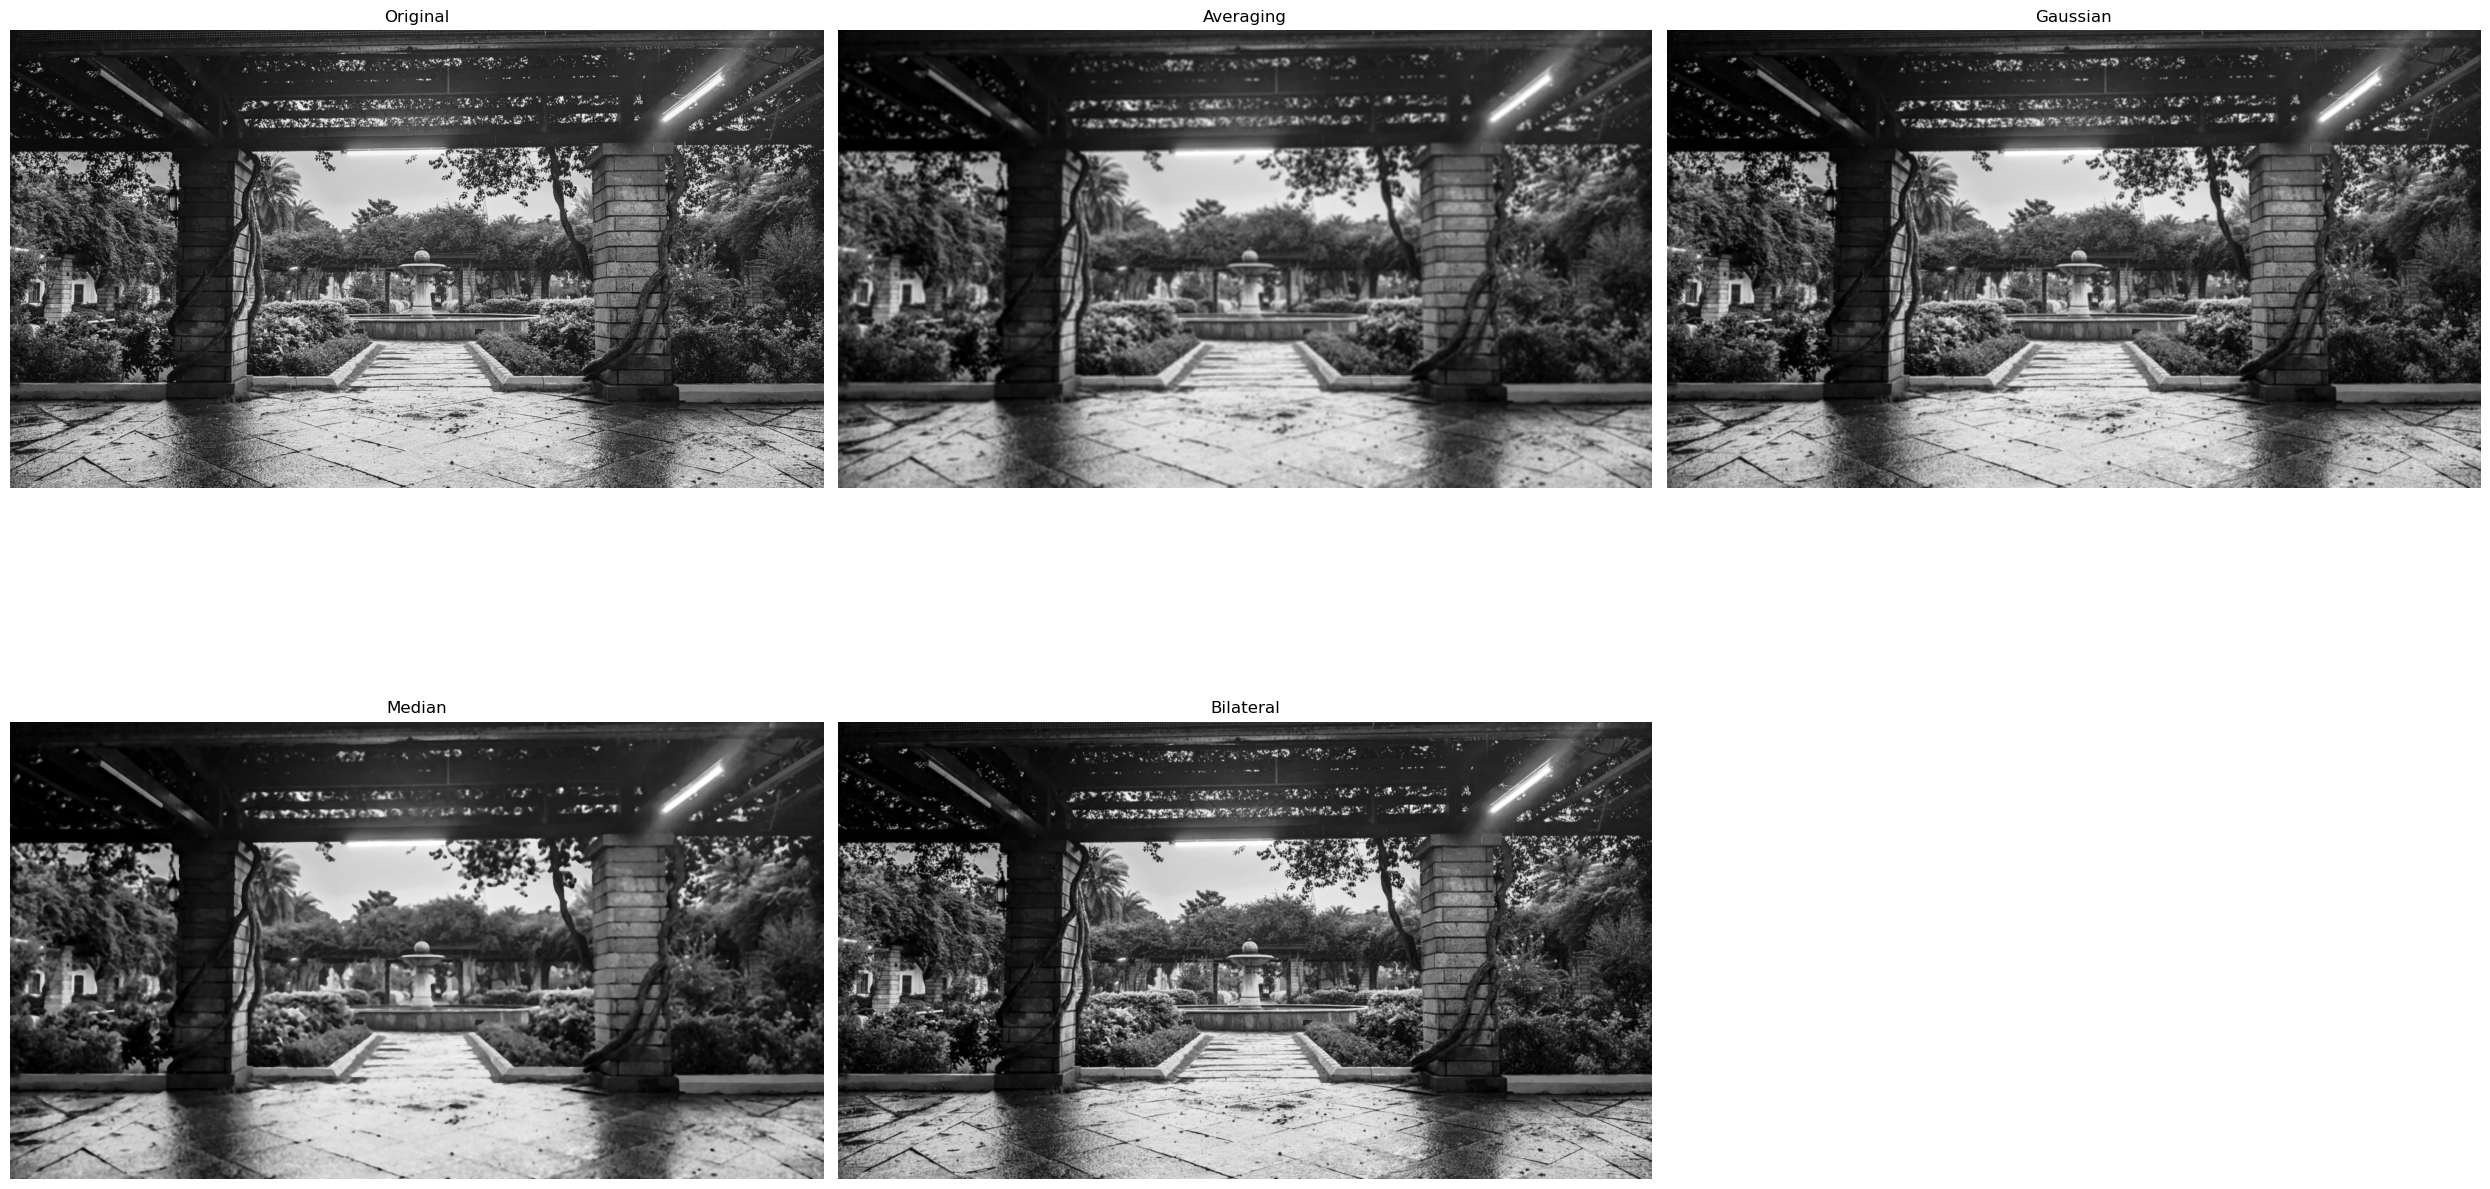

In [18]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('image.jpg', 0)

avg_blur = cv2.blur(img, (15,15))
gaussian_blur = cv2.GaussianBlur(img, (15,15), 0)
median_blur = cv2.medianBlur(img, 15)
bilateral_blur = cv2.bilateralFilter(img, 9, 75, 75)

plt.figure(figsize=(25,15))

images = [img, avg_blur, gaussian_blur, median_blur, bilateral_blur]
titles = ["Original", "Averaging", "Gaussian", "Median", "Bilateral"]

for i in range(5):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

Averaging and Gaussian filters smooth the image by reducing intensity variations, but may blur edges. Median filtering is effective in removing salt and pepper noise. Bilateral filtering smooths the image while preserving edges, making it more suitable for edge-sensitive applications.